# Analysis of Guitarburst Music Catalog
This notebook performs a descriptive and comparative analysis of the complete **`guitarburst_full.json`** catalog. 

Since all available matched files have been fully processed, we focus the analysis on comparing the pieces we have files for (**`found`**) against the pieces we don't have files for (**`not_found`**).

We analyze:
1. **Catalog Overview**: Descriptive statistics of the dataset.
2. **Difficulty Distribution**: Overall frequencies and density of difficulty levels (1–20) for the whole catalog, contrasted by status (`found` vs `not_found`).
3. **Status Breakdown by Difficulty**: The proportion of found pieces at each difficulty level.
4. **Difficulty by Status (Box & Violin plots)**: Comparing difficulty distributions between found and missing pieces.
5. **Historical Era Distribution**: Checking status and difficulty trends across musical eras.
6. **Difficulty vs Reading Score**: Assessing the relationship between difficulty and reading score.
7. **Composer Breakdown**: Analyzing top composers, their average difficulties, and what proportion of their catalog has been located.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set premium styling without forcing Windows-only fonts like Arial on Linux
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['figure.dpi'] = 120

# Load master JSON catalog
json_file_path = "guitarburst_full.json"
df_json = pd.read_json(json_file_path)

# Load verified pieces from Excel master list
excel_file_path = "verified pieces.xlsx"
df_excel = pd.read_excel(excel_file_path)

# Standardize Titles and Composers for exact matching (whitespace-stripped)
df_json['Title_clean'] = df_json['Title'].str.strip()
df_json['Composer_clean'] = df_json['Composer'].str.strip()
df_excel['Title_clean'] = df_excel['Title'].str.strip()
df_excel['Composer_clean'] = df_excel['Composer'].str.strip()

# Build a set of verified pieces based on Title and Composer
verified_keys = set(zip(df_excel['Title_clean'], df_excel['Composer_clean']))

# Split catalog into found (verified) and not_found (unverified) pieces
df_found_raw = df_excel.copy()
df_found_raw['status'] = 'found'

df_not_found_raw = df_json[~df_json.apply(
    lambda row: (row['Title_clean'], row['Composer_clean']) in verified_keys, axis=1
)].copy()
df_not_found_raw['status'] = 'not_found'

# Combine found and not_found datasets
# This preserves the 712 unique verified pieces from the Excel file and the 1584 not-found pieces from the JSON catalog.
df = pd.concat([df_found_raw, df_not_found_raw], ignore_index=True)

# Preprocess Difficulty and Reading columns
df['Difficulty'] = pd.to_numeric(df['Difficulty'], errors='coerce')
df['Reading'] = pd.to_numeric(df['Reading'], errors='coerce')

# Drop rows where Difficulty is missing (like the 'Error' difficulty in the Excel)
df_clean = df.dropna(subset=['Difficulty']).copy()
df_clean['Difficulty'] = df_clean['Difficulty'].astype(int)

print(f"Successfully loaded {len(df_excel)} rows from verified pieces Excel.")
print(f"Successfully loaded {len(df_json)} rows from master JSON catalog.")
print(f"Combined total: {len(df)} rows.")
print(f"{len(df_clean)} rows remaining after cleaning and parsing 'Difficulty'.")
print("\nPiece Status Counts in Cleaned Dataset:")
print(df_clean['status'].value_counts())


Successfully loaded 712 rows from verified pieces Excel.
Successfully loaded 2335 rows from master JSON catalog.
Combined total: 2296 rows.
2296 rows remaining after cleaning and parsing 'Difficulty'.

Piece Status Counts in Cleaned Dataset:
status
not_found    1584
found         712
Name: count, dtype: int64


## 1. Catalog Descriptive Statistics
Here we calculate descriptive statistics for the `Difficulty` column across the entire catalog, as well as separately for `found` and `not_found` pieces.


In [2]:
# Calculate descriptive stats
stats_all = df_clean['Difficulty'].describe()
stats_found = df_clean[df_clean['status'] == 'found']['Difficulty'].describe()
stats_not_found = df_clean[df_clean['status'] == 'not_found']['Difficulty'].describe()

stats_df = pd.DataFrame({
    'All Catalog': stats_all,
    'Found Pieces': stats_found,
    'Not Found Pieces': stats_not_found
})

# Add median and mode
stats_df.loc['median'] = [
    df_clean['Difficulty'].median(),
    df_clean[df_clean['status'] == 'found']['Difficulty'].median(),
    df_clean[df_clean['status'] == 'not_found']['Difficulty'].median()
]
stats_df.loc['mode'] = [
    df_clean['Difficulty'].mode().values[0],
    df_clean[df_clean['status'] == 'found']['Difficulty'].mode().values[0],
    df_clean[df_clean['status'] == 'not_found']['Difficulty'].mode().values[0]
]

print("Difficulty Descriptive Statistics:")
display(stats_df.round(2))


,All Catalog,Found Pieces,Not Found Pieces
count,2296.00,712.00,1584.00
mean,7.54,7.80,7.42
std,4.37,4.12,4.47
min,1.00,1.00,1.00
25%,4.00,5.00,4.00
50%,7.00,8.00,7.00
75%,10.00,10.25,10.00
max,20.00,20.00,20.00
median,7.00,8.00,7.00
mode,7.00,8.00,7.00


Difficulty Descriptive Statistics:


## 2. Difficulty Distribution (Found vs Not Found)
We compare the difficulty distribution of located (`found`) pieces against missing (`not_found`) pieces.


<string>:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


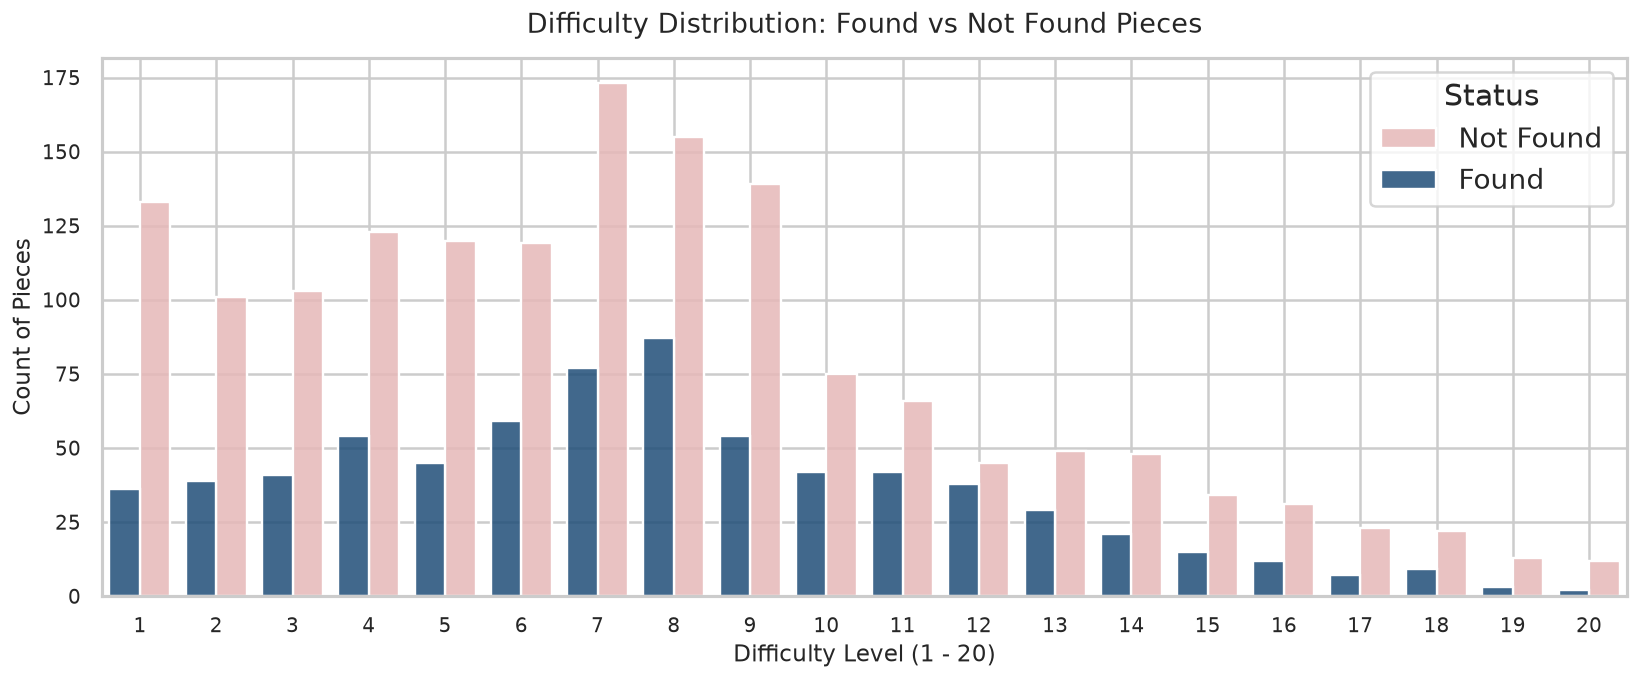

In [3]:
fig, ax = plt.subplots(figsize=(14, 6))

# Histogram comparing found vs not_found difficulty distribution
# Status category matches hue, legend=True, using soft colors
sns.histplot(
    data=df_clean, 
    x='Difficulty', 
    hue='status', 
    multiple='dodge',
    discrete=True, 
    shrink=0.8,
    palette=['#1F4E78', '#E6B8B8'],
    alpha=0.85, 
    ax=ax
)

ax.set_title("Difficulty Distribution: Found vs Not Found Pieces", pad=15)
ax.set_xlabel("Difficulty Level (1 - 20)")
ax.set_ylabel("Count of Pieces")
ax.set_xticks(range(1, 21))
ax.set_xlim(0.5, 20.5)
plt.legend(title="Status", labels=['Not Found', 'Found'])

plt.tight_layout()
plt.show()


## 3. Status Breakdown and Percent Found by Difficulty
We analyze what proportion of pieces at each difficulty level have been located.


status,not_found,found,Total,Found %
Difficulty,,,,
1,133,36,169,21.30
2,101,39,140,27.86
3,103,41,144,28.47
4,123,54,177,30.51
5,120,45,165,27.27
6,119,59,178,33.15
7,173,77,250,30.80
8,155,87,242,35.95
9,139,54,193,27.98


Status counts and percentage of pieces found by difficulty:


<string>:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


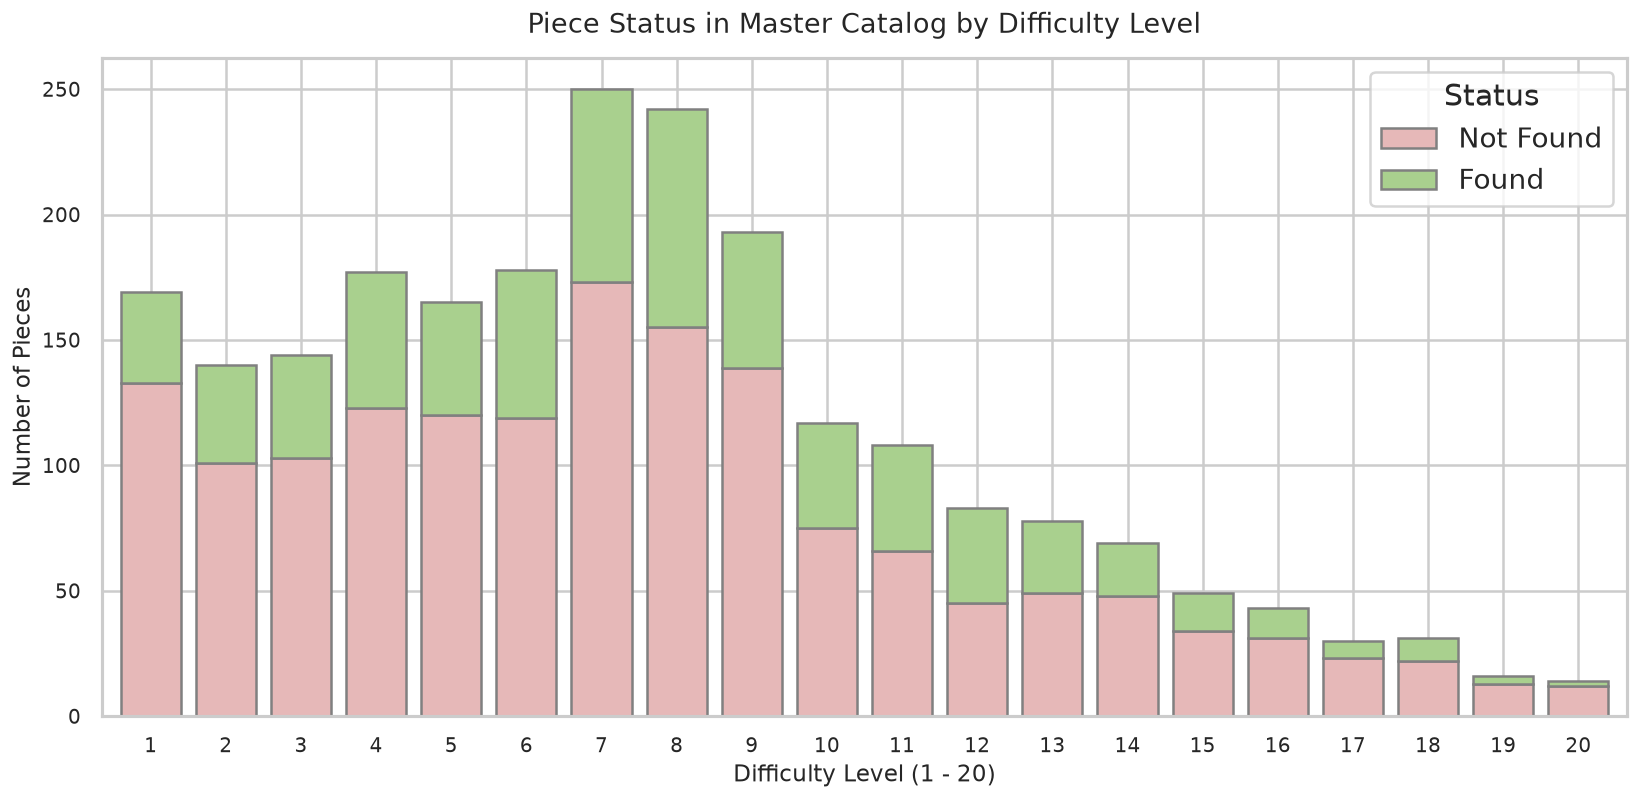

In [4]:
breakdown = df_clean.groupby(['Difficulty', 'status']).size().unstack(fill_value=0)
breakdown = breakdown[['not_found', 'found']]

fig, ax = plt.subplots(figsize=(14, 7))
breakdown.plot(
    kind='bar', 
    stacked=True, 
    color=['#E6B8B8', '#A9D08E'], 
    width=0.8, 
    edgecolor='gray',
    ax=ax
)

ax.set_title("Piece Status in Master Catalog by Difficulty Level", pad=15)
ax.set_xlabel("Difficulty Level (1 - 20)")
ax.set_ylabel("Number of Pieces")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.legend(title="Status", labels=['Not Found', 'Found'])
plt.tight_layout()
plt.show()

# Calculate percentages
breakdown['Total'] = breakdown.sum(axis=1)
breakdown['Found %'] = (breakdown['found'] / breakdown['Total'] * 100).round(2)
print("Status counts and percentage of pieces found by difficulty:")
display(breakdown)


## 4. Difficulty Distributions by Status (Box & Violin plots)
We check the overall spread and density of technical difficulty for located vs missing pieces.


<string>:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
<string>:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
<string>:37: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


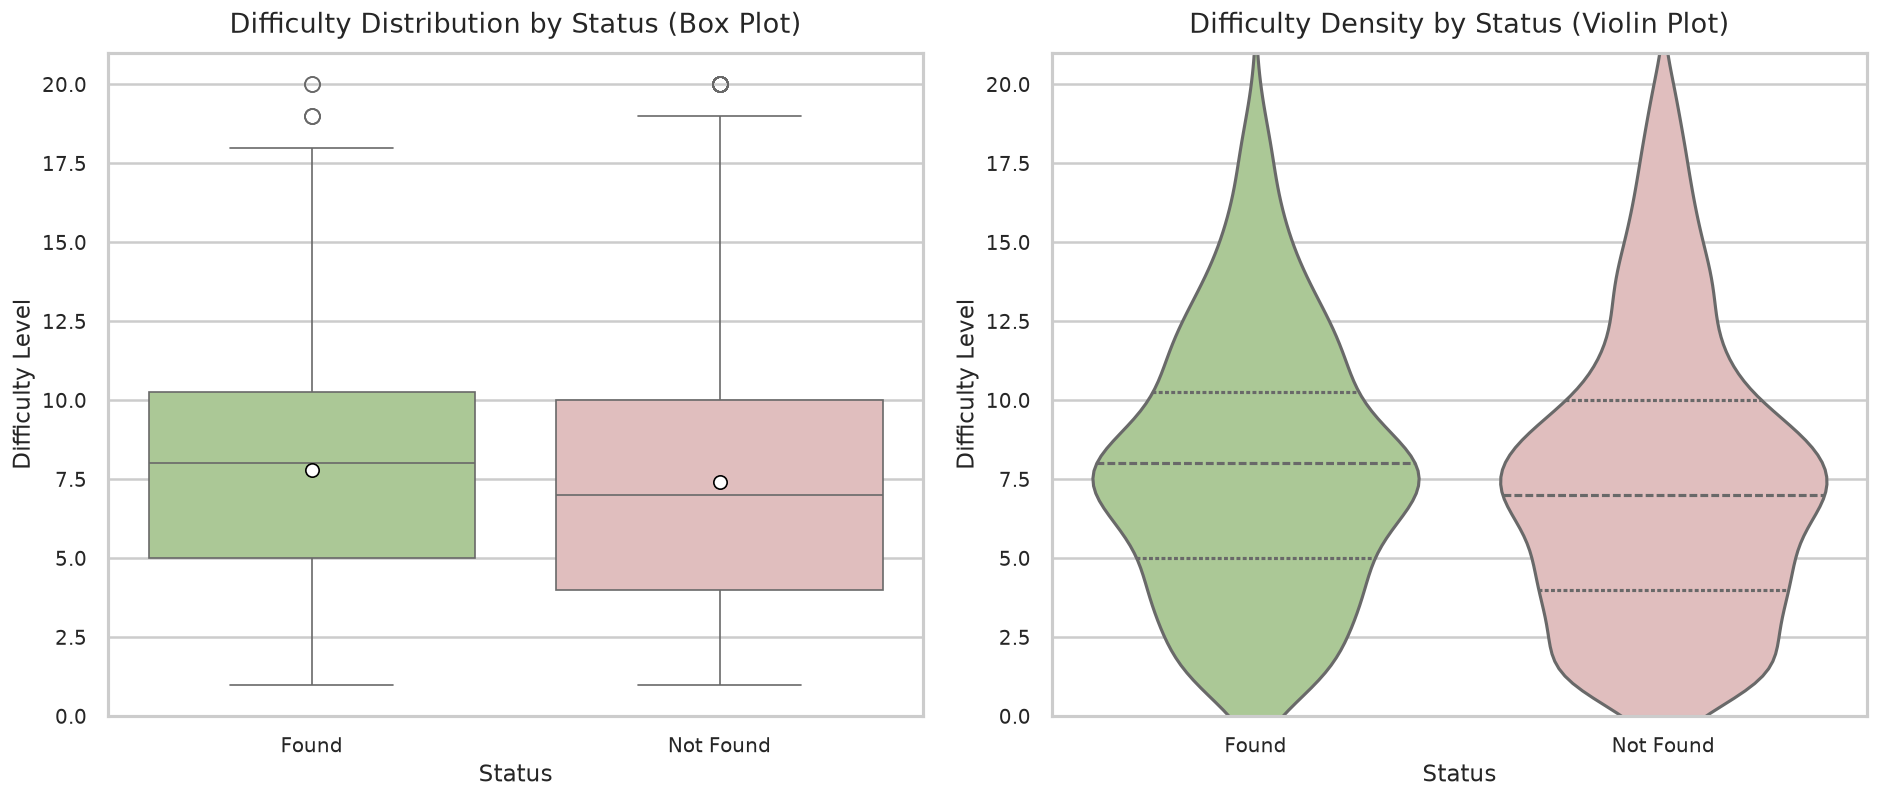

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

sns.boxplot(
    data=df_clean, 
    x='status', 
    y='Difficulty', 
    hue='status',
    legend=False,
    palette=['#A9D08E', '#E6B8B8'], 
    ax=ax1,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
)
ax1.set_title("Difficulty Distribution by Status (Box Plot)", pad=12)
ax1.set_xlabel("Status")
ax1.set_ylabel("Difficulty Level")
ax1.set_xticklabels(['Found', 'Not Found'])
ax1.set_ylim(0, 21)

sns.violinplot(
    data=df_clean, 
    x='status', 
    y='Difficulty', 
    hue='status',
    legend=False,
    palette=['#A9D08E', '#E6B8B8'], 
    inner='quartile', 
    ax=ax2
)
ax2.set_title("Difficulty Density by Status (Violin Plot)", pad=12)
ax2.set_xlabel("Status")
ax2.set_ylabel("Difficulty Level")
ax2.set_xticklabels(['Found', 'Not Found'])
ax2.set_ylim(0, 21)

plt.tight_layout()
plt.show()


## 5. Historical Era Status & Difficulty Trends
We check the proportion of located pieces across different historical musical periods and how difficulty shifts between them.


status,found,not_found,Total,Found %
Era,,,,
Renaissance,64,167,231,27.71
Baroque,149,326,475,31.37
Classical,218,375,593,36.76
Romantic,171,228,399,42.86
Modern,110,472,582,18.90
Traditional,0,16,16,0.00


Status Breakdown by Musical Era:


<string>:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


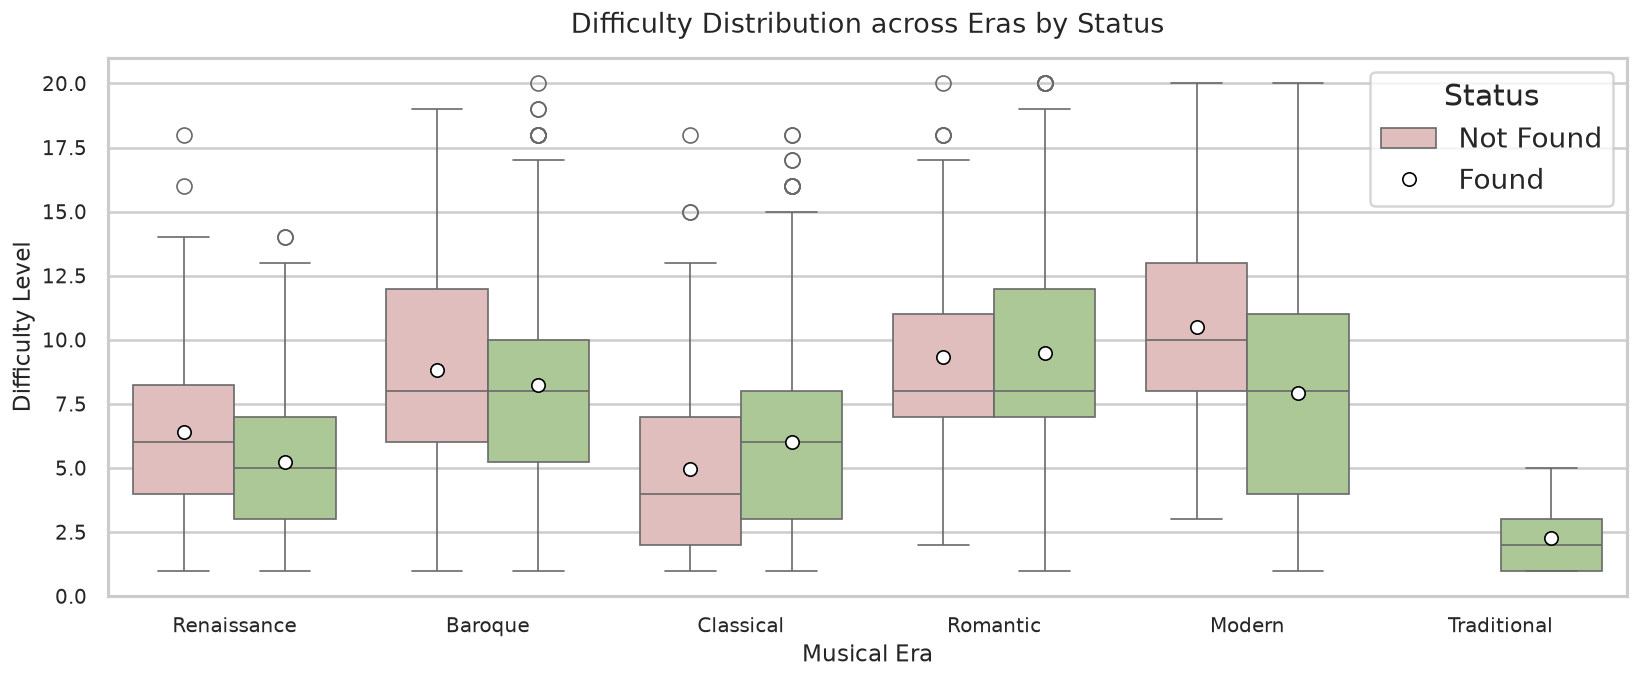

In [6]:
# Define chronological ordering of musical eras
era_order = ['Renaissance', 'Baroque', 'Classical', 'Romantic', 'Modern', 'Contemporary']
present_era_order = [e for e in era_order if e in df_clean['Era'].unique()]
other_eras = [e for e in df_clean['Era'].unique() if e not in present_era_order]
final_era_order = present_era_order + other_eras

fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=df_clean, 
    x='Era', 
    y='Difficulty', 
    hue='status',
    order=final_era_order,
    palette=['#E6B8B8', '#A9D08E'], 
    ax=ax,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
)

ax.set_title("Difficulty Distribution across Eras by Status", pad=15)
ax.set_xlabel("Musical Era")
ax.set_ylabel("Difficulty Level")
ax.set_ylim(0, 21)
plt.legend(title="Status", labels=['Not Found', 'Found'])
plt.tight_layout()
plt.show()

# Print era status counts
era_breakdown = df_clean.groupby(['Era', 'status']).size().unstack(fill_value=0).reindex(final_era_order)
era_breakdown['Total'] = era_breakdown.sum(axis=1)
era_breakdown['Found %'] = (era_breakdown['found'] / era_breakdown['Total'] * 100).round(2)
print("Status Breakdown by Musical Era:")
display(era_breakdown)


## 6. Relationship Between Difficulty and Reading Score
We check if there is a correlation between technical difficulty and reading score across the catalog.


Pearson Correlation between Difficulty and Reading Level: 0.8685


<string>:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


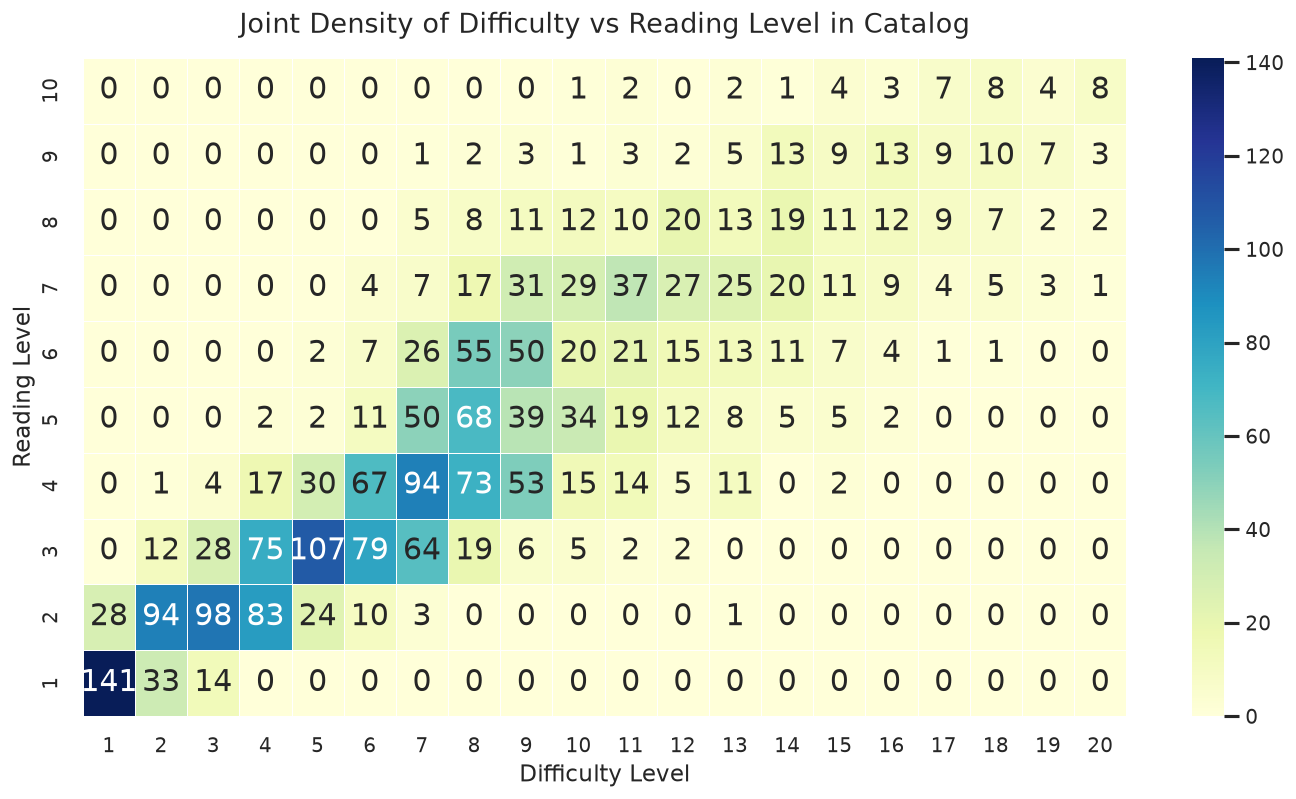

In [7]:
# Drop rows with missing Reading scores
df_reading = df_clean.dropna(subset=['Reading']).copy()
df_reading['Reading'] = df_reading['Reading'].astype(int)

cross_tab = pd.crosstab(df_reading['Reading'], df_reading['Difficulty'])

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    cross_tab, 
    cmap='YlGnBu', 
    annot=True, 
    fmt='d', 
    cbar=True, 
    linewidths=0.5, 
    ax=ax
)

ax.set_title("Joint Density of Difficulty vs Reading Level in Catalog", pad=15)
ax.set_xlabel("Difficulty Level")
ax.set_ylabel("Reading Level")
ax.invert_yaxis()

plt.tight_layout()
plt.show()

# Pearson Correlation
correlation = df_reading['Difficulty'].corr(df_reading['Reading'])
print(f"Pearson Correlation between Difficulty and Reading Level: {correlation:.4f}")


## 7. Composer breakdown, Found % and Average Difficulty
We highlight the top 15 most frequent composers in the catalog, look at how many of their pieces we have located, and compare their average difficulties.


<string>:43: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


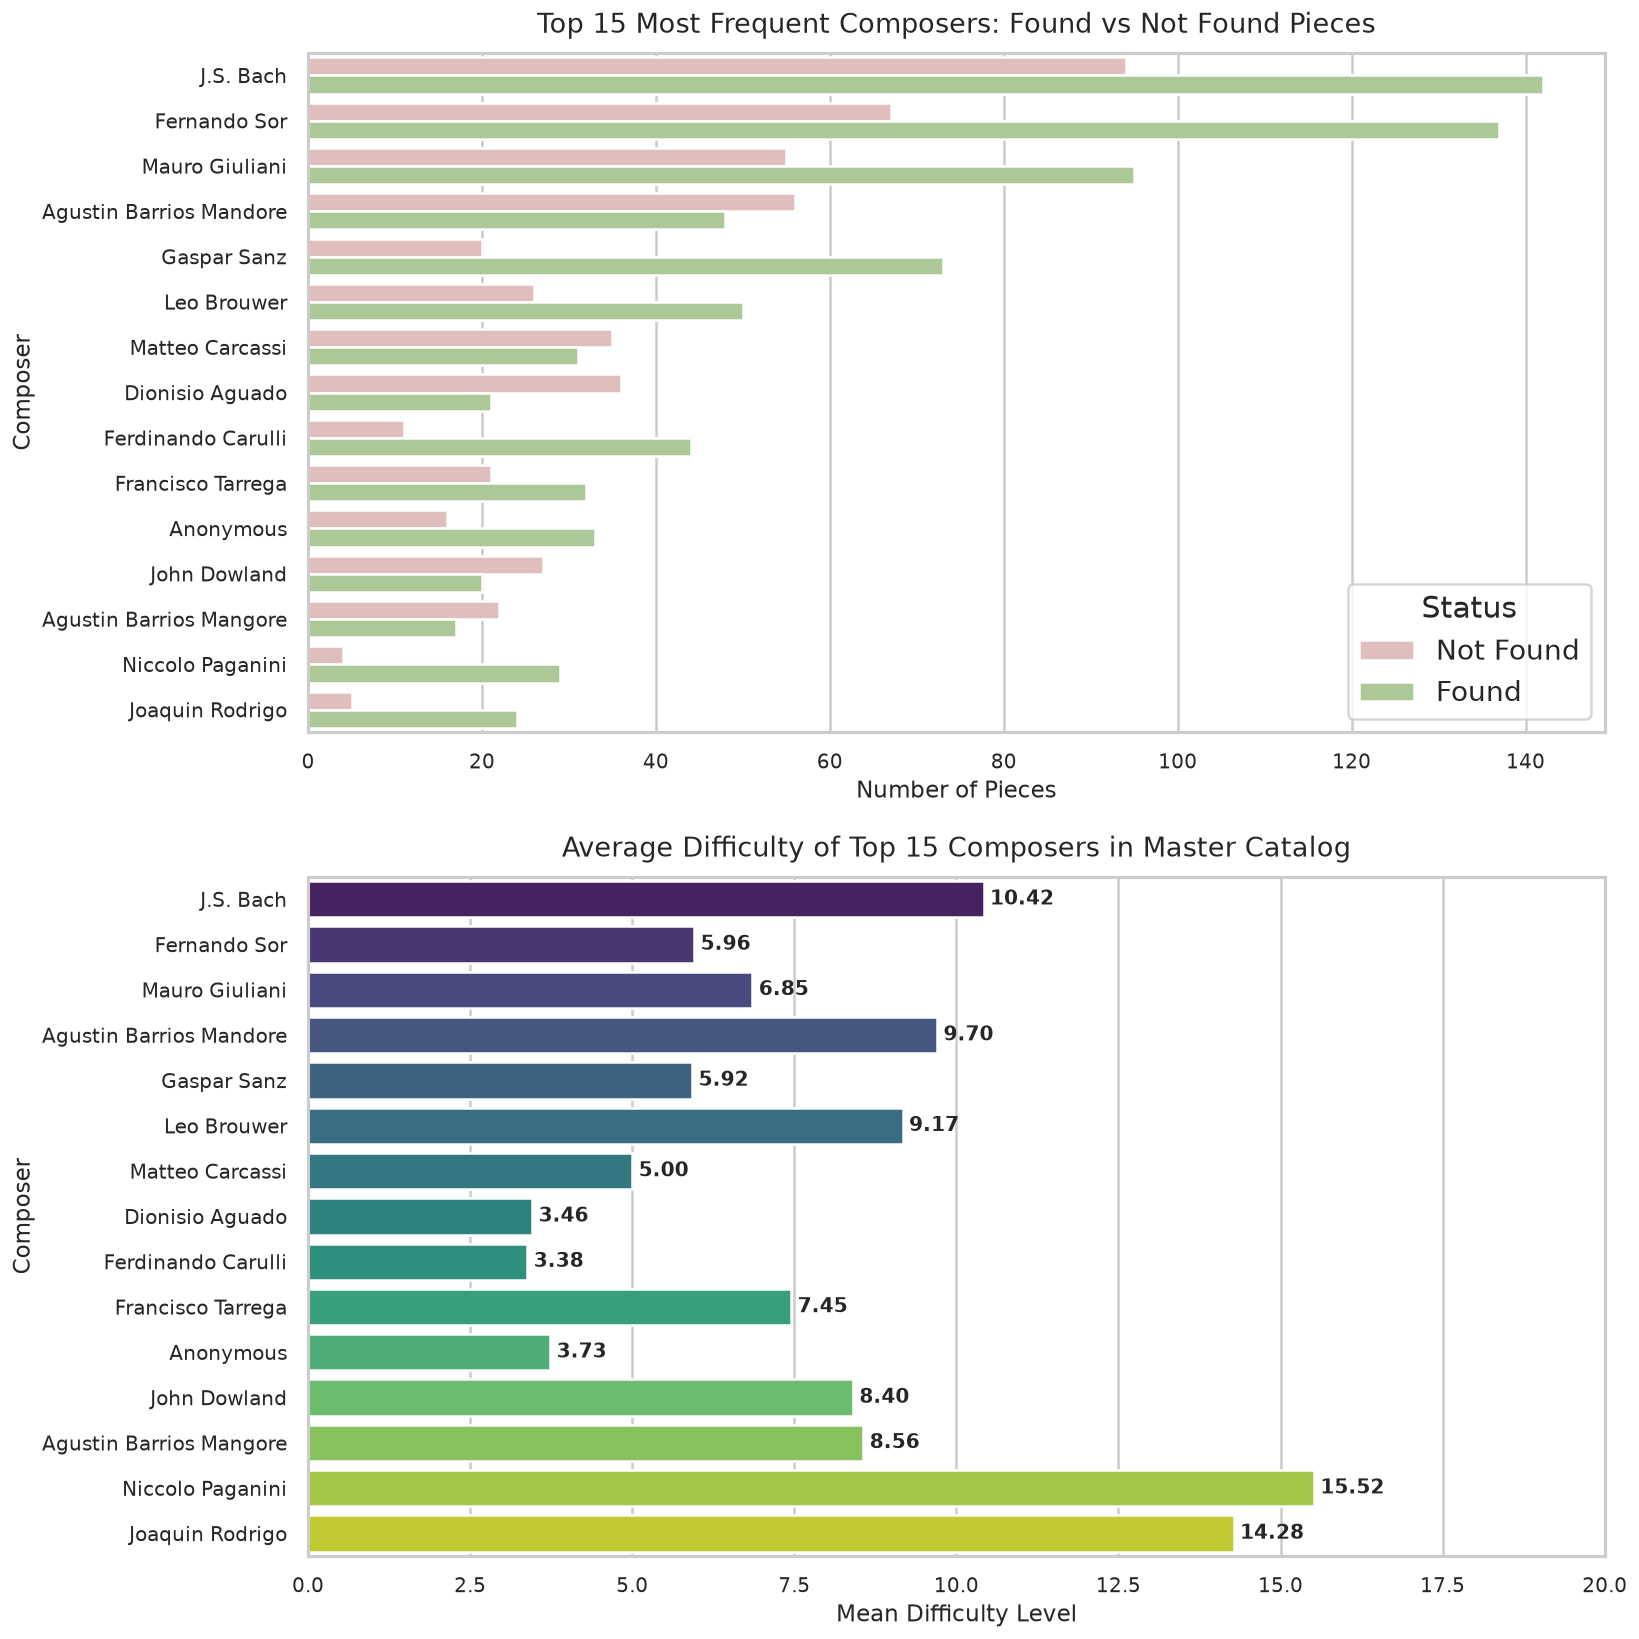

In [8]:
# Get top 15 composers in catalog
top_composers = df_clean['Composer'].value_counts().head(15).index
df_top_comp = df_clean[df_clean['Composer'].isin(top_composers)].copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 14))

# Status count breakdown per composer
sns.countplot(
    data=df_top_comp,
    y='Composer',
    order=top_composers,
    hue='status',
    palette=['#E6B8B8', '#A9D08E'],
    ax=ax1
)
ax1.set_title("Top 15 Most Frequent Composers: Found vs Not Found Pieces", pad=12)
ax1.set_xlabel("Number of Pieces")
ax1.set_ylabel("Composer")
ax1.legend(title="Status", labels=['Not Found', 'Found'])

# Average Difficulty
composer_avg_diff = df_top_comp.groupby('Composer')['Difficulty'].mean().reindex(top_composers)

sns.barplot(
    x=composer_avg_diff.values,
    y=composer_avg_diff.index,
    hue=composer_avg_diff.index,
    legend=False,
    palette='viridis',
    ax=ax2
)

# Label values
for i, v in enumerate(composer_avg_diff.values):
    ax2.text(v + 0.1, i, f"{v:.2f}", va='center', fontweight='bold', fontsize=12)

ax2.set_title("Average Difficulty of Top 15 Composers in Master Catalog", pad=12)
ax2.set_xlabel("Mean Difficulty Level")
ax2.set_ylabel("Composer")
ax2.set_xlim(0, 20)

plt.tight_layout()
plt.show()


## 8. Breakdown of Found Pieces by Source (Dada, Gaps, PDFs)
We analyze the composition of our located pieces based on their source category (`dada`, `gaps`, `pdf`) and examine their respective difficulty distributions.

,Count,Percentage (%),Min,Mean,Median,Mode,Max,Std Dev
source_clean,,,,,,,,
dada,49,6.88,1.0,7.94,7.0,11,19.0,4.69
gaps,12,1.69,1.0,5.50,4.5,4,11.0,3.12
pdf,651,91.43,1.0,7.84,8.0,8,20.0,4.08


Descriptive Statistics of Difficulty by Source:


<string>:73: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


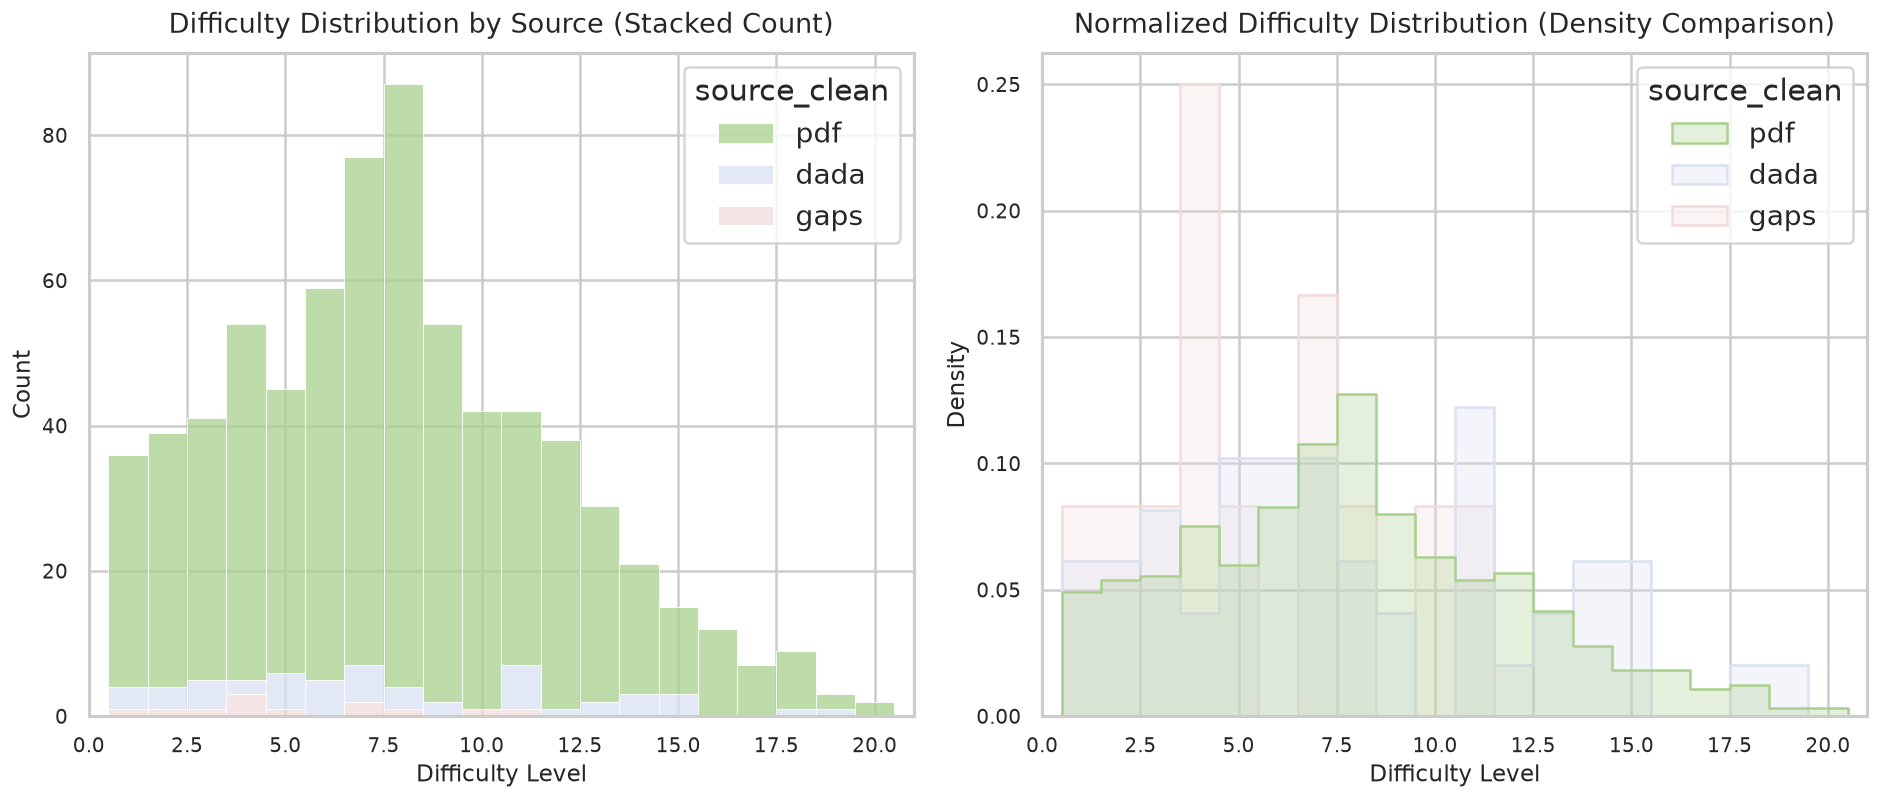

In [9]:
# Filter found pieces and standardize source labels
df_found = df_clean[df_clean['status'] == 'found'].copy()
df_found['source_clean'] = df_found['source'].map({
    'dada_gp': 'dada',
    'gaps': 'gaps',
    'pdf': 'pdf'
})

# Calculate piece counts and percentages
source_counts = df_found['source_clean'].value_counts()
source_pcts = df_found['source_clean'].value_counts(normalize=True) * 100

# Calculate difficulty statistics by source
difficulty_stats = df_found.groupby('source_clean')['Difficulty'].describe()
difficulty_stats['median'] = df_found.groupby('source_clean')['Difficulty'].median()
difficulty_stats['mode'] = df_found.groupby('source_clean')['Difficulty'].apply(lambda x: x.mode().values[0] if not x.mode().empty else np.nan)

# Combine into a summary DataFrame
summary_df = pd.DataFrame({
    'Count': source_counts,
    'Percentage (%)': source_pcts,
    'Min': difficulty_stats['min'],
    'Mean': difficulty_stats['mean'],
    'Median': difficulty_stats['median'],
    'Mode': difficulty_stats['mode'],
    'Max': difficulty_stats['max'],
    'Std Dev': difficulty_stats['std']
})

print("Descriptive Statistics of Difficulty by Source:")
display(summary_df.round(2))

# Plot the difficulty distributions by source using histograms
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Left subplot: Stacked histogram (absolute count)
sns.histplot(
    data=df_found,
    x='Difficulty',
    hue='source_clean',
    multiple='stack',
    palette=['#A9D08E', '#D9E1F2', '#F2DCDB'],
    discrete=True,
    edgecolor='white',
    linewidth=0.5,
    ax=ax1
)
ax1.set_title("Difficulty Distribution by Source (Stacked Count)", pad=12)
ax1.set_xlabel("Difficulty Level")
ax1.set_ylabel("Count")
ax1.set_xlim(0, 21)

# Right subplot: Normalized step histogram (relative density shape)
sns.histplot(
    data=df_found,
    x='Difficulty',
    hue='source_clean',
    element='step',
    stat='density',
    common_norm=False,
    fill=True,
    palette=['#A9D08E', '#D9E1F2', '#F2DCDB'],
    discrete=True,
    alpha=0.3,
    ax=ax2
)
ax2.set_title("Normalized Difficulty Distribution (Density Comparison)", pad=12)
ax2.set_xlabel("Difficulty Level")
ax2.set_ylabel("Density")
ax2.set_xlim(0, 21)

plt.tight_layout()
plt.show()